# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [17]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [18]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print("Tỷ lệ missing của tất cả các cột:")
print(df.isnull().mean())

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
df = df.drop(columns=[col for col in leaky if col in df.columns])
print("\nCác cột còn lại:", list(df.columns))

Tỷ lệ missing của tất cả các cột:
survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64

Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

- Cột alive có các giá trị (yes / no) tương ứng trực tiếp tỉ lệ 1-1 với cột mục tiêu survived ($1 \leftrightarrow \text{yes}$, $0 \leftrightarrow \text{no}$). Việc giữ cột này trong dữ liệu huấn luyện tương đương với việc cung cấp trước nhãn mục tiêu cho mô hình. Mô hình sẽ đạt độ chính xác gần như 100% bằng cách học mối quan hệ tầm thường này, nhưng sẽ mất hoàn toàn khả năng dự đoán khi triển khai thực tế trên các dữ liệu mới (nơi chúng ta chưa biết trước hành khách đó sống hay chết).

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [19]:
# TODO 2: shape, info, describe
print("Kích thước dữ liệu (shape):", df.shape)
print("\nThông tin cấu trúc dữ liệu (info):")
df.info()
print("\nThống kê mô tả biến số:")
display(df.describe())
print("\nThống kê mô tả biến phân loại:")
display(df.describe(include=['object', 'category']))

Kích thước dữ liệu (shape): (891, 8)

Thông tin cấu trúc dữ liệu (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB

Thống kê mô tả biến số:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Thống kê mô tả biến phân loại:


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

- Biến mục tiêu (Target): survived.
- Biến số (Numerical variables): age (số thực/độ tuổi), sibsp (số nguyên/số anh chị em, vợ chồng), parch (số nguyên/số cha mẹ, con cái), fare (số thực/giá vé).
- Biến phân loại (Categorical variables): sex (định danh - nominal), embarked (định danh - nominal), pclass (thứ tự - ordinal).

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [20]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_table = pd.DataFrame({'Số lượng khuyết': missing_count, 'Tỷ lệ khuyết (%)': missing_pct})
display(missing_table[missing_table['Số lượng khuyết'] > 0])

,Số lượng khuyết,Tỷ lệ khuyết (%)
age,177,19.865320
embarked,2,0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| `age` | ~19.87% | Điền khuyết bằng `median` (trung vị) | Tỷ lệ thiếu tương đối lớn (~20%). Sử dụng trung vị giúp bền vững trước các giá trị ngoại lai ở hai đầu cực (trẻ em dưới 5 tuổi và người già trên 70 tuổi), tránh làm thay đổi nhiều phân phối tự nhiên của biến độ tuổi. |
| `embarked` | ~0.22% | Điền khuyết bằng `mode` (giá trị phổ biến nhất) | Tỷ lệ khuyết thiếu cực kỳ nhỏ (chỉ có 2 dòng). Điền bằng giá trị xuất hiện nhiều nhất (cảng Southampton - 'S') là phương pháp đơn giản nhất mà không làm thay đổi hay gây nhiễu cho phân phối dữ liệu phân loại. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [21]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    s_clean = s.dropna()
    q1 = s_clean.quantile(0.25)
    q3 = s_clean.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((s_clean < lower) | (s_clean > upper)).sum()
def dem_outlier_zscore(s, nguong=3.0):
    s_clean = s.dropna()
    z_scores = np.abs(stats.zscore(s_clean))
    return (z_scores > nguong).sum()
for col in ["age", "fare"]:
    print(f"Cột {col}:")
    print(f"  - Outliers (IQR): {dem_outlier_iqr(df[col])}")
    print(f"  - Outliers (Z-score): {dem_outlier_zscore(df[col])}")

Cột age:
  - Outliers (IQR): 11
  - Outliers (Z-score): 2
Cột fare:
  - Outliers (IQR): 116
  - Outliers (Z-score): 20


**Trả lời 4 (quyết định với outlier của `fare`):**

- Đối với outlier của fare, chúng ta nên giữ lại thay vì loại bỏ hay biến đổi. Lý do là các vé có giá cao bất thường này đại diện cho những hành khách đi khoang hạng Nhất sang trọng (First class), đây là các giá trị thực tế chứ không phải do sai sót nhập liệu. Thông tin về giá vé cao này tương quan rất mạnh với khả năng sống sót của hành khách (do những người giàu có được ưu tiên tiếp cận xuồng cứu sinh). Nếu loại bỏ các outlier này, mô hình sẽ mất đi các đặc trưng mang tính phân loại cực kỳ giá trị.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

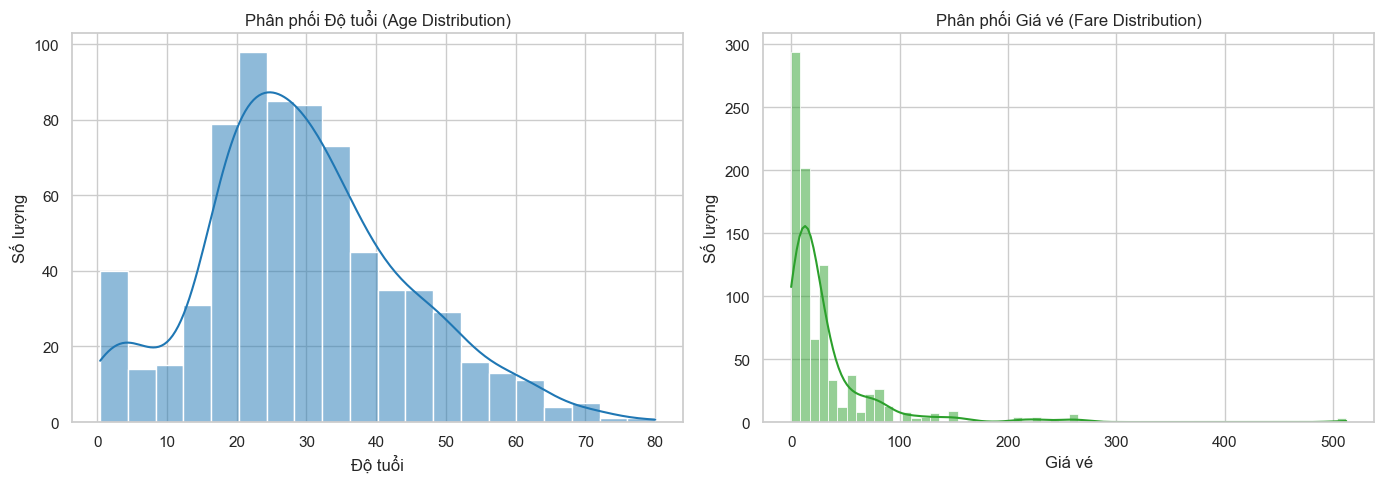

In [22]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='age', kde=True, ax=axes[0], color='tab:blue')
axes[0].set_title('Phân phối Độ tuổi (Age Distribution)')
axes[0].set_xlabel('Độ tuổi')
axes[0].set_ylabel('Số lượng')
sns.histplot(data=df, x='fare', kde=True, ax=axes[1], color='tab:green')
axes[1].set_title('Phân phối Giá vé (Fare Distribution)')
axes[1].set_xlabel('Giá vé')
axes[1].set_ylabel('Số lượng')
plt.tight_layout()
plt.show()

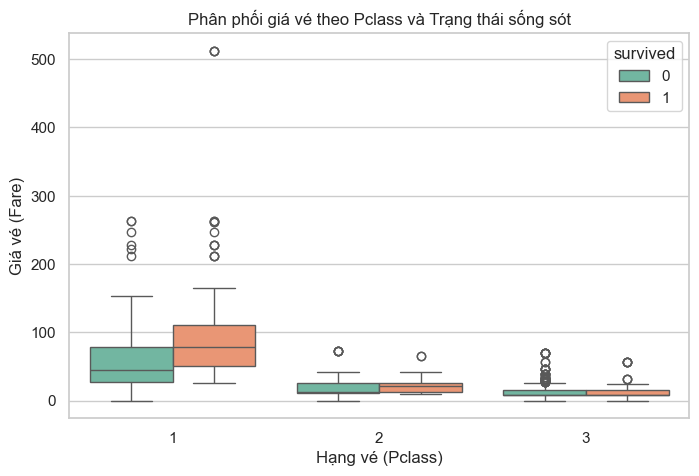

In [23]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='pclass', y='fare', hue='survived', palette='Set2')
plt.title('Phân phối giá vé theo Pclass và Trạng thái sống sót')
plt.xlabel('Hạng vé (Pclass)')
plt.ylabel('Giá vé (Fare)')
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_18624\738806377.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='survived', errorbar=None, palette='pastel', ax=axes[0])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_18624\738806377.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='pclass', y='survived', errorbar=None, palette='muted', ax=axes[1])


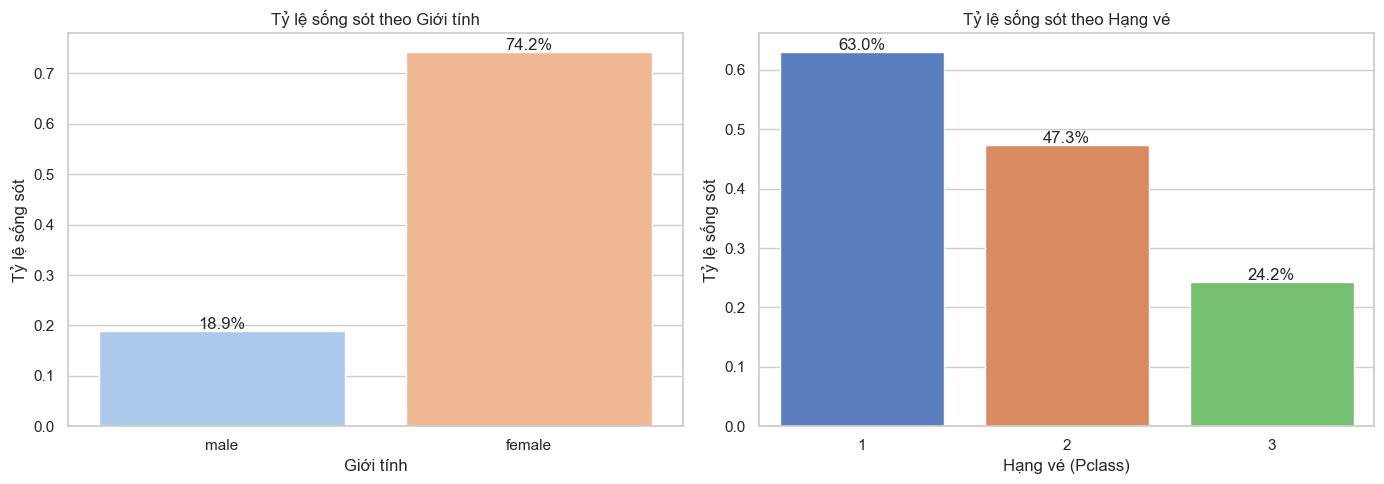

In [24]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='sex', y='survived', errorbar=None, palette='pastel', ax=axes[0])
axes[0].set_title('Tỷ lệ sống sót theo Giới tính')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Tỷ lệ sống sót')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
sns.barplot(data=df, x='pclass', y='survived', errorbar=None, palette='muted', ax=axes[1])
axes[1].set_title('Tỷ lệ sống sót theo Hạng vé')
axes[1].set_xlabel('Hạng vé (Pclass)')
axes[1].set_ylabel('Tỷ lệ sống sót')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

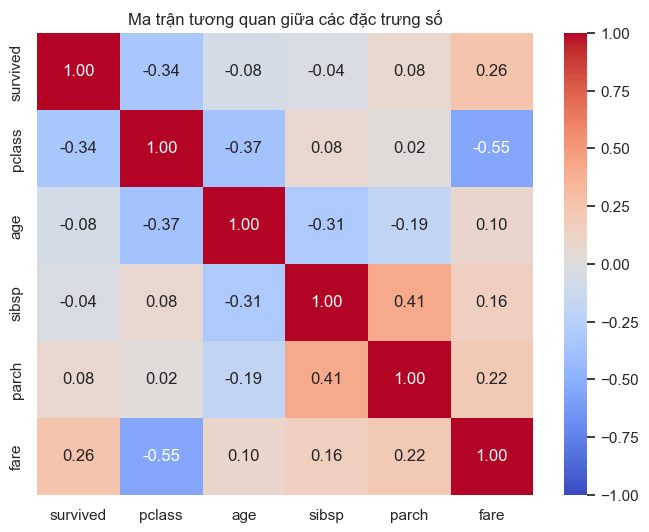

In [25]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa các đặc trưng số')
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: Phân phối tuổi age gần với phân phối chuẩn nhưng hơi lệch phải và có một nhóm đỉnh nhỏ ở phân khúc trẻ em dưới 5 tuổi. Trái lại, phân phối giá vé fare bị lệch phải cực kỳ nghiêm trọng, đa số hành khách mua vé giá rẻ dưới 50 USD và có một số rất ít hành khách mua vé cực đắt lên tới hơn 500 USD.
- Boxplot: Giá vé của hạng 1 cao hơn rất nhiều và xuất hiện nhiều giá trị ngoại lai lớn. Ở cả 3 hạng vé, những hành khách sống sót (survived=1) đều có xu hướng trả giá vé trung vị cao hơn so với những người không sống sót.
- Bar survival: Nữ giới có tỷ lệ sống sót vượt trội (~74.2%) so với nam giới (~18.9%), chứng minh hiệu quả của nguyên tắc cứu hộ ưu tiên phụ nữ. Hạng vé cũng ảnh hưởng mạnh đến cơ hội sống sót: Hạng 1 (63.0%), Hạng 2 (47.3%) và Hạng 3 (24.2%).
- Heatmap: Tương quan giữa fare và pclass là tương quan nghịch mạnh (-0.55), điều này dễ hiểu vì hạng vé nhỏ hơn (ví dụ Hạng 1) thì giá vé cao hơn. survived có mối tương quan nghịch rõ rệt nhất với pclass (-0.34) và tương quan thuận với fare (0.26).

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [26]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=['survived'])
y = df['survived']
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15 / 0.85, random_state=42, stratify=y_tmp
)
print(f"Train set: {X_train.shape}, Val set: {X_val.shape}, Test set: {X_test.shape}")
print(f"Tỷ lệ survived trong Train: {y_train.mean():.4f}")
print(f"Tỷ lệ survived trong Val: {y_val.mean():.4f}")
print(f"Tỷ lệ survived trong Test: {y_test.mean():.4f}")

Train set: (623, 7), Val set: (134, 7), Test set: (134, 7)
Tỷ lệ survived trong Train: 0.3836
Tỷ lệ survived trong Val: 0.3881
Tỷ lệ survived trong Test: 0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [27]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])
pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocess = ColumnTransformer([
    ('num', pipe_so,  num_cols),
    ('cat', pipe_cat, cat_cols),
    ('ord', 'passthrough', ord_cols),
])
preprocess.fit(X_train)
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)
print("Shape tập train sau tiền xử lý:", X_train_t.shape)
print("Tên các cột đầu ra:", list(preprocess.get_feature_names_out()))

Shape tập train sau tiền xử lý: (623, 10)
Tên các cột đầu ra: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

- Khi tiền xử lý, phương thức .fit() được dùng để tính toán các tham số thống kê của đặc trưng (ví dụ: giá trị median để điền khuyết, median và IQR dùng trong RobustScaler). Nếu chúng ta fit trên toàn bộ dữ liệu hoặc gộp cả tập test/val trước khi fit, các giá trị của tập test/val sẽ tham gia vào tính toán các tham số này, làm rò rỉ thông tin của tập test/val vào tập train (data leakage). Khi đó mô hình sẽ có điểm số đánh giá ảo vì nó đã gián tiếp biết thông tin của tập test. Bằng cách chỉ .fit() trên X_train và chỉ .transform() trên val/test, ta đảm bảo mô hình hoàn toàn không biết gì về phân phối của tập validation và test trước khi dự đoán.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [28]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print("Phân phối số lượng nhãn của 'survived':")
print(df['survived'].value_counts())
print("\nTỷ lệ phần trạng các lớp:")
print(df['survived'].value_counts(normalize=True))

Phân phối số lượng nhãn của 'survived':
survived
0    549
1    342
Name: count, dtype: int64

Tỷ lệ phần trạng các lớp:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Mức độ mất cân bằng: Lớp 0 (không sống sót) chiếm khoảng 61.6% và lớp 1 (sống sót) chiếm khoảng 38.4%. Đây là mức mất cân bằng nhẹ đến vừa, chưa đến mức quá nghiêm trọng.
2. Accuracy bị đánh lừa khi nào: Accuracy bị đánh lừa khi dữ liệu mất cân bằng cực kỳ nghiêm trọng (ví dụ: 99% lớp 0 và 1% lớp 1). Trong trường hợp đó, một mô hình chỉ cần dự đoán ngây thơ là toàn bộ hành khách đều tử vong vẫn đạt được độ chính xác 99% trên lý thuyết, nhưng lại hoàn toàn vô dụng vì không phát hiện được bất kỳ hành khách nào sống sót.
3. Metric ưu tiên: Ta nên ưu tiên F1-Score (hoặc ROC-AUC). Lý do: F1-Score là trung bình điều hòa của Precision và Recall, giúp cân bằng cả hai yếu tố: giảm thiểu dự đoán sai lệch (sai số loại 1 và loại 2) và cực kỳ phù hợp khi đánh giá các mô hình phân loại trên dữ liệu có sự mất cân bằng giữa các lớp.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng tương quan mạnh nhất: Giới tính (sex) và hạng vé (pclass) là những yếu tố có mối tương quan mạnh nhất với khả năng sống sót. Số liệu cho thấy tỷ lệ sống sót của nữ giới cao gấp gần 4 lần nam giới (~74.2% so với ~18.9%), và hành khách hạng vé 1 có cơ hội sống cao gấp gần 2.6 lần hành khách hạng 3 (~63.0% so với ~24.2%).
2. Cột thiếu nhiều nhất và cách xử lý: Cột age thiếu nhiều nhất với tỷ lệ ~19.87% (sau khi đã drop các cột thừa). Trong pipeline tiền xử lý, ta sử dụng SimpleImputer điền khuyết bằng median để tránh ảnh hưởng bởi giá trị ngoại lai.
3. Mức độ mất cân bằng và ảnh hưởng: Tỷ lệ nhãn mục tiêu survived là 61.6% (chết) và 38.4% (sống). Do sự mất cân bằng ở mức trung bình này, việc sử dụng Accuracy làm metric duy nhất có thể gây ra nhận định chủ quan sai lầm, do đó F1-Score cần được ưu tiên. 
4. Kỹ thuật scaling và encoding: Các đặc trưng liên tục như age và fare cần được scaling (sử dụng RobustScaler thay vì StandardScaler do cột fare có outliers lớn và phân phối lệch phải mạnh). Các đặc trưng phân loại định danh như sex và embarked cần One-Hot Encoding để mô hình toán học có thể tính toán.
5. Điểm thú vị quan sát được: Một quan sát bất ngờ là mặc dù số lượng hành khách hạng 3 đông nhất nhưng tỷ lệ sống sót của họ lại thấp nhất, trong khi giá vé hạng 1 dao động rất lớn (từ rất rẻ đến cực đắt), thể hiện rõ sự phân hóa cơ hội sống sót theo tầng lớp xã hội tại thời điểm thảm họa xảy ra.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [29]:
# (tùy chọn) code cho phần Bonus
...

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
